# Deepfake Voice Detection — Model Training
### Step 2 of 4: Extract MFCC features, Train and Compare Multiple Models, evaluate, and save model
---

## Step 1 — Import Libraries

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import pickle
import time

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2 — Load Paths

In [2]:
# AUTO PATH DETECTION — works on any machine
BASE_DIR           = os.path.dirname(os.path.abspath('__file__'))
REAL_CHUNKS_FOLDER = os.path.join(BASE_DIR, 'dataset', 'real_chunks')
FAKE_CHUNKS_FOLDER = os.path.join(BASE_DIR, 'dataset', 'fake_chunks')
MODELS_DIR         = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH      = os.path.join(MODELS_DIR, 'model.pkl')
SCALER_PATH     = os.path.join(MODELS_DIR, 'scaler.pkl')
REAL_MEANS_PATH = os.path.join(MODELS_DIR, 'real_means.npy')
REAL_STDS_PATH  = os.path.join(MODELS_DIR, 'real_stds.npy')

print(f'Project directory  : {BASE_DIR}')
print(f'Real chunks folder : {REAL_CHUNKS_FOLDER}')
print(f'Fake chunks folder : {FAKE_CHUNKS_FOLDER}')
print(f'Models folder      : {MODELS_DIR}')

Project directory  : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection
Real chunks folder : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\dataset\real_chunks
Fake chunks folder : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\dataset\fake_chunks
Models folder      : d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\models


## Step 3 — Load Chunk Files from Dataset

In [3]:
TARGET_SR     = 16000
TARGET_LENGTH = 3 * TARGET_SR  # 48000 samples

real_chunk_files = sorted([f for f in os.listdir(REAL_CHUNKS_FOLDER) if f.endswith('.wav')])
fake_chunk_files = sorted([f for f in os.listdir(FAKE_CHUNKS_FOLDER) if f.endswith('.wav')])

print(f'Real chunk files : {len(real_chunk_files)}')
print(f'Fake chunk files : {len(fake_chunk_files)}')
print(f'Total chunks     : {len(real_chunk_files) + len(fake_chunk_files)}')

if len(real_chunk_files) == 0 or len(fake_chunk_files) == 0:
    print('\nERROR: No chunk files found!')
    print('Please run 01_data_preparation.ipynb first.')
else:
    print('\nChunk files loaded. Ready for feature extraction.')

Real chunk files : 536
Fake chunk files : 327
Total chunks     : 863

Chunk files loaded. Ready for feature extraction.


## Step 4 — Extract MFCC Features
Convert all audio chunks into numbers that the model can learn from.
- MFCC = Mel Frequency Cepstral Coefficients
- Each 3-second chunk produces 40 numbers describing its voice pattern
- Real and fake voices have different MFCC patterns

In [4]:
def extract_mfcc(file_path, n_mfcc=40):
    '''Extract 40 MFCC features from a 3-second audio chunk.'''
    try:
        audio, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
        mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc, axis=1)
    except Exception as e:
        print(f'Error: {file_path} -> {e}')
        return None

X, y = [], []

print('Extracting features from real chunks...')
for fname in sorted(real_chunk_files):
    features = extract_mfcc(os.path.join(REAL_CHUNKS_FOLDER, fname))
    if features is not None:
        X.append(features)
        y.append(0)  # 0 = real
print(f'Real features extracted : {sum(1 for l in y if l == 0)}')

print('\nExtracting features from fake chunks...')
for fname in sorted(fake_chunk_files):
    features = extract_mfcc(os.path.join(FAKE_CHUNKS_FOLDER, fname))
    if features is not None:
        X.append(features)
        y.append(1)  # 1 = fake
print(f'Fake features extracted : {sum(1 for l in y if l == 1)}')

X = np.array(X)
y = np.array(y)

print(f'\nFeature matrix : {X.shape[0]} samples x {X.shape[1]} features')
print(f'Real samples   : {np.sum(y == 0)}')
print(f'Fake samples   : {np.sum(y == 1)}')
print('Feature extraction complete! Ready for training.')

Extracting features from real chunks...
Real features extracted : 536

Extracting features from fake chunks...
Fake features extracted : 327

Feature matrix : 863 samples x 40 features
Real samples   : 536
Fake samples   : 327
Feature extraction complete! Ready for training.


## Step 5 — Train/Test Split and Normalize
Split 80% for training and 20% for testing. Normalize all features to the same scale.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Total samples    : {len(X)}')
print(f'Training samples : {len(X_train)} (80%)')
print(f'Testing samples  : {len(X_test)} (20%)')
print(f'Training Real    : {sum(y_train == 0)}  |  Training Fake : {sum(y_train == 1)}')
print(f'Testing  Real    : {sum(y_test == 0)}   |  Testing  Fake : {sum(y_test == 1)}')
print('Split complete! Ready for model training.')

Total samples    : 863
Training samples : 690 (80%)
Testing samples  : 173 (20%)
Training Real    : 429  |  Training Fake : 261
Testing  Real    : 107   |  Testing  Fake : 66
Split complete! Ready for model training.


## Step 6 — Train and Compare Multiple Models
Training three different classifiers on the extracted MFCC features and selecting the best one automatically.

- **Random Forest** — 100 decision trees voting together, fast and reliable
- **Gradient Boosting** — learns from previous mistakes, often higher accuracy
- **SVM** — finds the best boundary between real and fake voice patterns

All three models use `class_weight='balanced'` to handle the imbalance between real (536) and fake (327) chunks.
The best performing model is automatically saved for report generation.

In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pickle
import os

# ── Define all 3 models ───────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators  = 100,
        random_state  = 42,
        class_weight  = 'balanced',
        n_jobs        = -1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators  = 100,
        random_state  = 42,
        learning_rate = 0.1
    ),
    'SVM': SVC(
        kernel        = 'rbf',
        class_weight  = 'balanced',
        probability   = True,
        random_state  = 42
    )
}

# ── Train and evaluate all models ─────────────────────────────────────────
import time

results_comparison = {}

print('=' * 55)
print('         TRAINING ALL MODELS')
print('=' * 55)

for name, m in models.items():
    print(f'\nTraining {name}...')
    start = time.time()
    m.fit(X_train, y_train)
    end   = time.time()

    y_pred = m.predict(X_test)
    acc    = accuracy_score(y_test, y_pred) * 100

    results_comparison[name] = {
        'model'    : m,
        'accuracy' : acc,
        'time'     : round(end - start, 2)
    }

    print(f'✅ {name}')
    print(f'   Accuracy : {acc:.1f}%')
    print(f'   Time     : {end - start:.2f} seconds')

# ── Comparison summary ────────────────────────────────────────────────────
print(f'\n{"=" * 55}')
print(f'         MODEL COMPARISON SUMMARY')
print(f'{"=" * 55}')
for name, res in results_comparison.items():
    bar     = '█' * int(res['accuracy'] / 5)
    print(f'{name:25} → {res["accuracy"]:.1f}%  {bar}')

# ── Pick best model automatically ────────────────────────────────────────
best_name  = max(results_comparison,
                 key=lambda x: results_comparison[x]['accuracy'])
best_model = results_comparison[best_name]['model']
best_acc   = results_comparison[best_name]['accuracy']

print(f'\n{"=" * 55}')
print(f'Best Model : {best_name}')
print(f'Accuracy   : {best_acc:.1f}%')
print(f'{"=" * 55}')
print(f'\n✅ Best model selected automatically for saving!')

         TRAINING ALL MODELS

Training Random Forest...
✅ Random Forest
   Accuracy : 95.4%
   Time     : 0.69 seconds

Training Gradient Boosting...
✅ Gradient Boosting
   Accuracy : 92.5%
   Time     : 4.06 seconds

Training SVM...
✅ SVM
   Accuracy : 98.8%
   Time     : 0.35 seconds

         MODEL COMPARISON SUMMARY
Random Forest             → 95.4%  ███████████████████
Gradient Boosting         → 92.5%  ██████████████████
SVM                       → 98.8%  ███████████████████

Best Model : SVM
Accuracy   : 98.8%

✅ Best model selected automatically for saving!


## Step 7 — Evaluate the Best Model
Test the best performing model on unseen data and measure performance.
- Precision : of all predicted fake, how many were actually fake
- Recall    : of all actual fake, how many did we correctly detect
- F1 Score  : balance between precision and recall
- Best model is selected automatically based on highest accuracy

     SVM EVALUATION RESULTS
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99       107
        Fake       0.97      1.00      0.99        66

    accuracy                           0.99       173
   macro avg       0.99      0.99      0.99       173
weighted avg       0.99      0.99      0.99       173



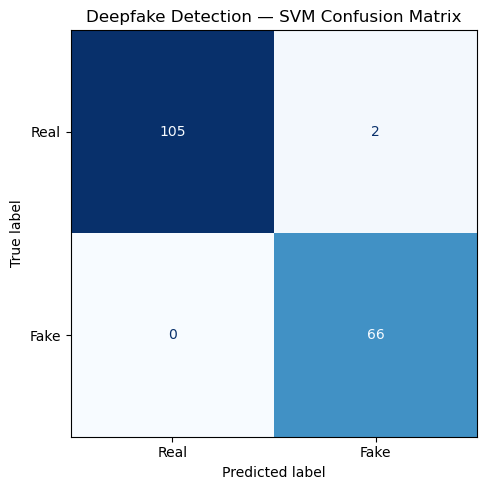

Overall accuracy : 98.8%
Excellent! Model is performing very well.


In [7]:
# Evaluate best model (SVM)
y_pred = best_model.predict(X_test)

print('=' * 50)
print(f'     {best_name.upper()} EVALUATION RESULTS')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title(f'Deepfake Detection — {best_name} Confusion Matrix')
plt.tight_layout()
plt.show()

total    = len(y_test)
correct  = sum(y_pred == y_test)
accuracy = correct / total * 100
print(f'Overall accuracy : {accuracy:.1f}%')
if accuracy >= 90:
    print('Excellent! Model is performing very well.')
elif accuracy >= 80:
    print('Good! Model is performing well.')
elif accuracy >= 70:
    print('Acceptable. Model needs some improvement.')
else:
    print('Model needs significant improvement.')

## Step 8 — Save Random Forest Model and Scaler
Random Forest is saved specifically for SHAP compatibility — TreeExplainer only supports tree-based models.
- model.pkl      : Random Forest classifier (selected for SHAP compatibility)
- scaler.pkl     : normalization scaler fitted on training data
- real_means.npy : mean MFCC values of real voices (used in report range charts)
- real_stds.npy  : standard deviation of real voice MFCC values (used in report range charts)
- model_info.txt : records Random Forest as the saved model and its accuracy

In [8]:
from datetime import datetime
import numpy as np

MODELS_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH  = os.path.join(MODELS_DIR, 'model.pkl')
SCALER_PATH = os.path.join(MODELS_DIR, 'scaler.pkl')

# Save Random Forest specifically — required for SHAP TreeExplainer compatibility
rf_model = results_comparison['Random Forest']['model']
rf_acc   = results_comparison['Random Forest']['accuracy']

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(rf_model, f)

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

# Save real voice statistics for report range charts
real_idx   = [i for i, l in enumerate(y_train) if l == 0]
real_feats = X_train[real_idx]
real_means = np.mean(real_feats, axis=0)
real_stds  = np.std(real_feats,  axis=0)

MEANS_PATH = os.path.join(MODELS_DIR, 'real_means.npy')
STDS_PATH  = os.path.join(MODELS_DIR, 'real_stds.npy')
np.save(MEANS_PATH, real_means)
np.save(STDS_PATH,  real_stds)

# Save model info
INFO_PATH = os.path.join(MODELS_DIR, 'model_info.txt')
with open(INFO_PATH, 'w') as f:
    f.write(f'Saved Model   : Random Forest\n')
    f.write(f'Accuracy      : {rf_acc:.1f}%\n')
    f.write(f'Note          : Random Forest selected for SHAP compatibility (TreeExplainer requires tree-based models)\n')
    f.write(f'Training date : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Dataset size  : {len(X)} chunks\n')
    f.write(f'Real chunks   : {sum(y == 0)}\n')
    f.write(f'Fake chunks   : {sum(y == 1)}\n')
    f.write(f'\nAll model accuracies:\n')
    for name, res in results_comparison.items():
        f.write(f'  {name:25} : {res["accuracy"]:.1f}%\n')

# Verify all files saved
model_size  = os.path.getsize(MODEL_PATH)  / 1024
scaler_size = os.path.getsize(SCALER_PATH) / 1024
means_size  = os.path.getsize(MEANS_PATH)  / 1024
stds_size   = os.path.getsize(STDS_PATH)   / 1024

print(f'{"=" * 50}')
print(f'All files saved to: {MODELS_DIR}')
print(f'{"=" * 50}')
print(f'model.pkl       : {model_size:.1f} KB  (Random Forest)')
print(f'scaler.pkl      : {scaler_size:.1f} KB')
print(f'real_means.npy  : {means_size:.1f} KB')
print(f'real_stds.npy   : {stds_size:.1f} KB')
print(f'model_info.txt  : saved')
print(f'{"=" * 50}')
print(f'Saved model : Random Forest at {rf_acc:.1f}% accuracy')
print(f'Note        : Random Forest selected for SHAP compatibility')
print(f'{"=" * 50}')

All files saved to: d:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\models
model.pkl       : 882.3 KB  (Random Forest)
scaler.pkl      : 1.4 KB
real_means.npy  : 0.3 KB
real_stds.npy   : 0.3 KB
model_info.txt  : saved
Saved model : Random Forest at 95.4% accuracy
Note        : Random Forest selected for SHAP compatibility
